# PROYECTO FINAL
## 02. Extracción y limpieza

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Cargar el dataset optimizado (Pandas lo descomprime automáticamente)
print("Cargando la muestra optimizada...")
df = pd.read_csv('../datos/01_dataset_limpio_y_unificado.csv.gz')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. CALCULAR MÉTRICA ESTRELLA: Consumo por metro cuadrado por hora
df['kwh_per_sqm'] = df['kwh'] / df['sqm']

print(f"\n¡Dataset cargado con éxito! Filas: {df.shape[0]:,}")
print("Columnas actuales de trabajo:", df.columns.tolist())

Cargando la muestra optimizada...

¡Dataset cargado con éxito! Filas: 5,314,912
Columnas actuales de trabajo: ['timestamp', 'building_id', 'kwh', 'tipo_consumo', 'primaryspaceusage', 'sqm', 'yearbuilt', 'numberoffloors', 'airTemperature', 'leed_level', 'kwh_per_sqm']


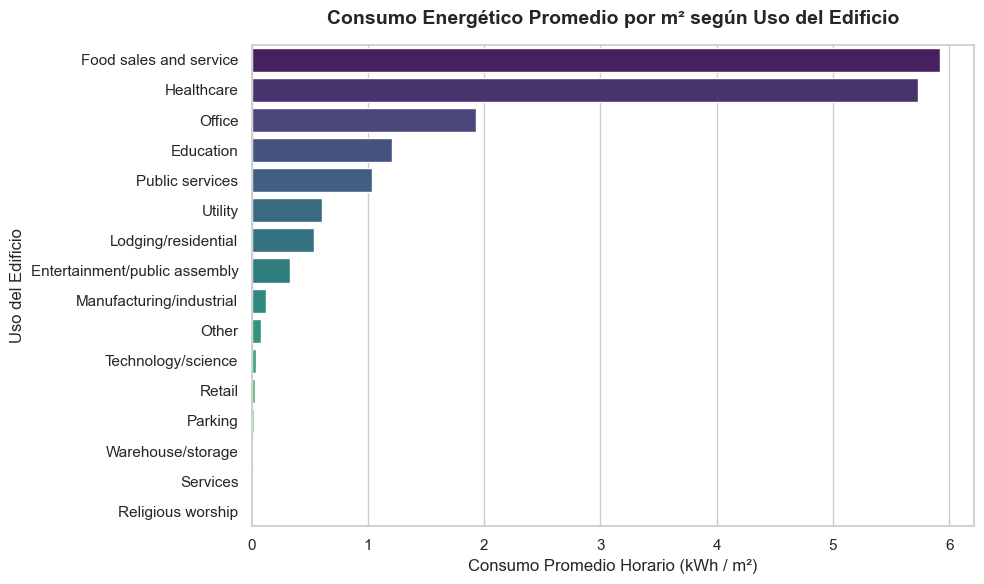

¡Gráfico 01 generado y guardado en la carpeta 'graficos'!


In [4]:
# Configurar estilo visual limpio y profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Agrupar por uso de edificio y calcular el promedio de nuestra métrica estrella
df_usos = df.groupby('primaryspaceusage')['kwh_per_sqm'].mean().sort_values(ascending=False).reset_index()

# Crear el gráfico de barras utilizando la paleta profesional 'viridis'
sns.barplot(data=df_usos, x='kwh_per_sqm', y='primaryspaceusage', palette='viridis', hue='primaryspaceusage', legend=False)

# Personalización de etiquetas
plt.title('Consumo Energético Promedio por m² según Uso del Edificio', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Consumo Promedio Horario (kWh / m²)', fontsize=12)
plt.ylabel('Uso del Edificio', fontsize=12)
plt.tight_layout()

# GUARDAR GRÁFICO AUTOMÁTICAMENTE para tu presentación PowerPoint
plt.savefig('../graficos/01_consumo_por_uso.png', dpi=300)
plt.show()

print("¡Gráfico 01 generado y guardado en la carpeta 'graficos'!")

Clasificación según normativa térmica

In [5]:
# 1. Crear una función para clasificar los años en épocas constructivas
def clasificar_epoca(año):
    if pd.isna(año):
        return 'Desconocido'
    elif año < 1970:
        return '1. Antes de 1970 (Aislamiento mínimo/nulo)'
    elif 1970 <= año < 1990:
        return '2. 1970 - 1990 (Aislamiento básico)'
    elif 1990 <= año < 2006:
        return '3. 1990 - 2006 (Normativa moderna)'
    else:
        return '4. Después de 2006 (Alta eficiencia / CTE)'

# 2. Aplicar la función a nuestro dataset creando una nueva columna categórica
df['epoca_construccion'] = df['yearbuilt'].apply(clasificar_epoca)

# Verificar cuántos registros tenemos por cada época
print("Registros analizados por época constructiva:")
print(df['epoca_construccion'].value_counts().sort_index())

Registros analizados por época constructiva:
epoca_construccion
1. Antes de 1970 (Aislamiento mínimo/nulo)    1176786
2. 1970 - 1990 (Aislamiento básico)            550930
3. 1990 - 2006 (Normativa moderna)             339637
4. Después de 2006 (Alta eficiencia / CTE)     318931
Desconocido                                   2928628
Name: count, dtype: int64


C:\Users\ivan_\AppData\Local\Temp\ipykernel_16864\1674627656.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


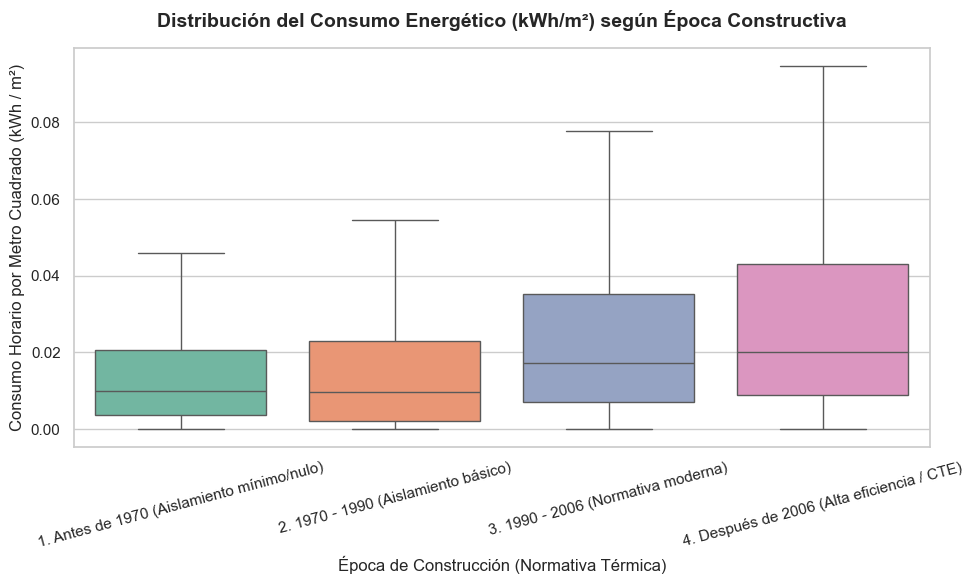

¡Gráfico 02 generado y guardado con éxito!


In [7]:
plt.figure(figsize=(10, 6))

# Filtramos los 'Desconocidos' para no ensuciar el gráfico técnico
df_filtrado_epocas = df[df['epoca_construccion'] != 'Desconocido']

# Creamos el boxplot. Usamos showfliers=False para ocultar los outliers extremos y ver bien las cajas
sns.boxplot(
    data=df_filtrado_epocas, 
    x='epoca_construccion', 
    y='kwh_per_sqm', 
    palette='Set2', 
    order=sorted(df_filtrado_epocas['epoca_construccion'].unique()),
    showfliers=False
)

plt.title('Distribución del Consumo Energético (kWh/m²) según Época Constructiva', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Época de Construcción (Normativa Térmica)', fontsize=12)
plt.ylabel('Consumo Horario por Metro Cuadrado (kWh / m²)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

# Guardar automáticamente en la carpeta de gráficos
plt.savefig('../graficos/02_consumo_por_antiguedad.png', dpi=300)
plt.show()

print("¡Gráfico 02 generado y guardado con éxito!")

Registros de oficinas a analizar: 321,471


C:\Users\ivan_\AppData\Local\Temp\ipykernel_16864\1909815840.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


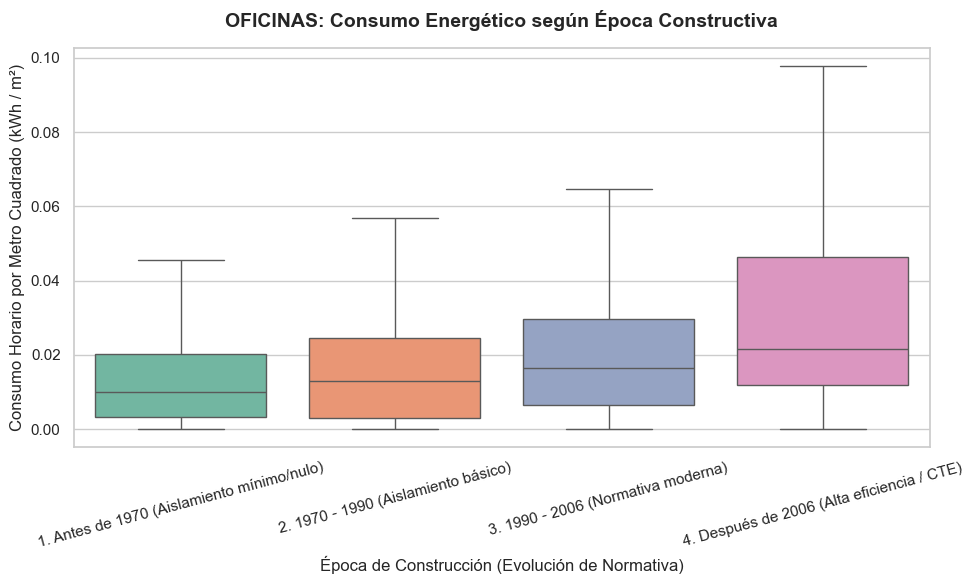

¡Gráfico de control de oficinas generado!


In [9]:
# 1. Creamos un dataset que contenga ÚNICAMENTE oficinas
df_oficinas = df[(df['primaryspaceusage'] == 'Office') & (df['epoca_construccion'] != 'Desconocido')].copy()

print(f"Registros de oficinas a analizar: {df_oficinas.shape[0]:,}")

# 2. Pintamos de nuevo el Boxplot solo para Oficinas
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_oficinas, 
    x='epoca_construccion', 
    y='kwh_per_sqm', 
    palette='Set2', 
    order=sorted(df_oficinas['epoca_construccion'].unique()),
    showfliers=False # Mantenemos los outliers ocultos para comparar limpiamente las cajas
)

plt.title('OFICINAS: Consumo Energético según Época Constructiva', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Época de Construcción (Evolución de Normativa)', fontsize=12)
plt.ylabel('Consumo Horario por Metro Cuadrado (kWh / m²)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

# Guardamos este gráfico corregido sustituyendo o añadiendo al inventario
plt.savefig('../graficos/02b_consumo_antiguedad_oficinas.png', dpi=300)
plt.show()

print("¡Gráfico de control de oficinas generado!")

Registros residenciales a analizar: 287,513


C:\Users\ivan_\AppData\Local\Temp\ipykernel_16864\4289557931.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


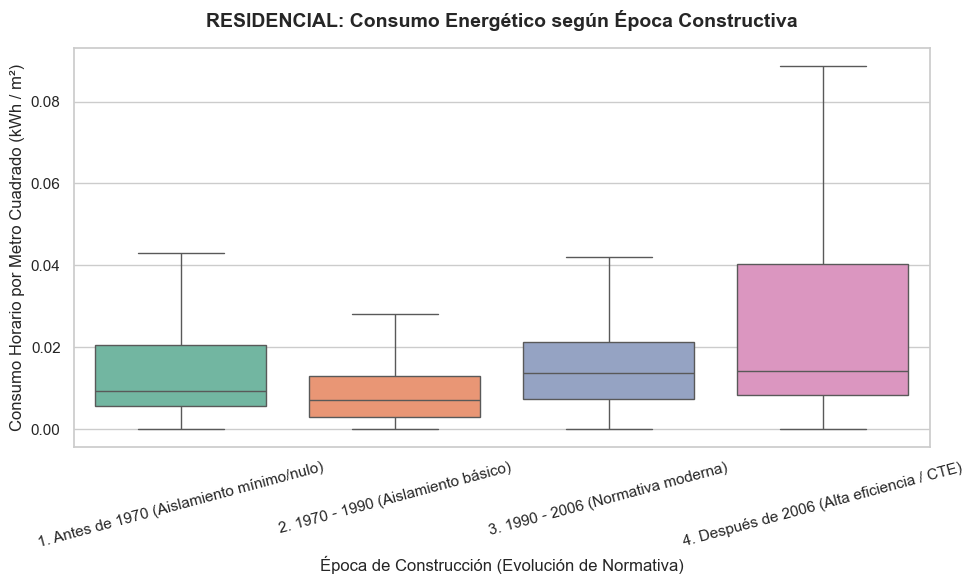

¡Gráfico de control residencial generado con éxito!


In [12]:
# 1. Filtramos el dataset para quedarnos ÚNICAMENTE con el uso residencial/hoteles
df_residencial = df[(df['primaryspaceusage'] == 'Lodging/residential') & (df['epoca_construccion'] != 'Desconocido')].copy()

print(f"Registros residenciales a analizar: {df_residencial.shape[0]:,}")

# 2. Pintamos el Boxplot solo para Residencial
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_residencial, 
    x='epoca_construccion', 
    y='kwh_per_sqm', 
    palette='Set2', 
    order=sorted(df_residencial['epoca_construccion'].unique()),
    showfliers=False # Mantenemos los outliers ocultos para ver las cajas limpias
)

plt.title('RESIDENCIAL: Consumo Energético según Época Constructiva', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Época de Construcción (Evolución de Normativa)', fontsize=12)
plt.ylabel('Consumo Horario por Metro Cuadrado (kWh / m²)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()

# Guardamos este nuevo gráfico en tu carpeta
plt.savefig('../graficos/02c_consumo_antiguedad_residencial.png', dpi=300)
plt.show()

print("¡Gráfico de control residencial generado con éxito!")

In [14]:
print(df_oficinas['tipo_consumo'].unique())

['Electricidad General' 'Agua refrigerada (AC)']


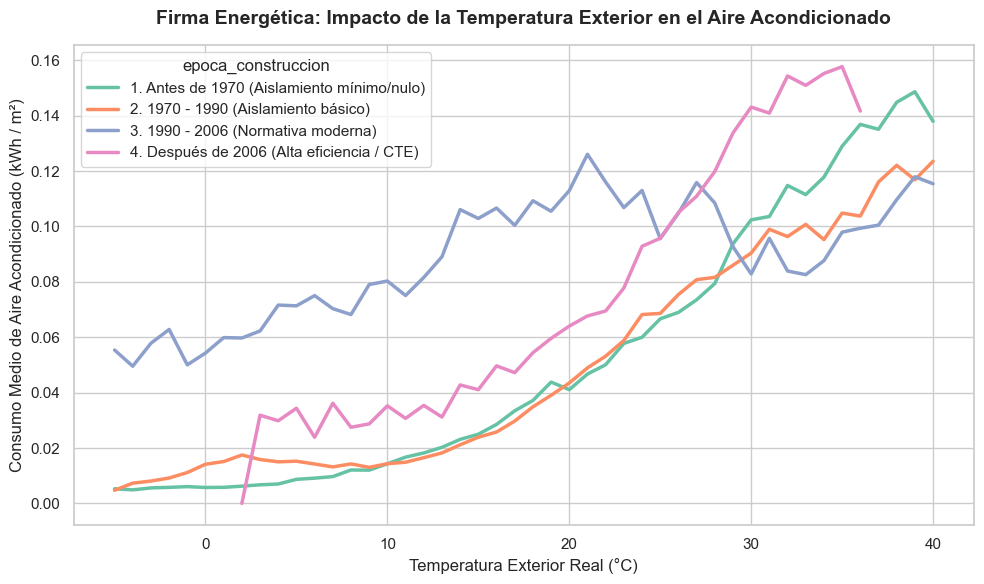

¡Gráfico de Gemelo Digital generado con éxito a partir de 70,379 lecturas horarias!


In [16]:
# 1. FILTRADO CON LA ETIQUETA EXACTA
df_clima_oficinas = df_oficinas[df_oficinas['tipo_consumo'] == 'Agua refrigerada (AC)'].copy()

# Limpieza climática: filtramos un rango de temperaturas lógicas de trabajo (-5°C a 40°C) 
# para eliminar valores atípicos del sensor meteorológico
df_clima_oficinas = df_clima_oficinas[(df_clima_oficinas['airTemperature'] >= -5) & (df_clima_oficinas['airTemperature'] <= 40)]

# Redondeamos la temperatura exterior a números enteros para agrupar las lecturas horarias
df_clima_oficinas['temp_entera'] = df_clima_oficinas['airTemperature'].round()

# 2. AGRUPACIÓN: Calcular el consumo medio por cada grado de temperatura y época
df_correlacion = df_clima_oficinas.groupby(['temp_entera', 'epoca_construccion'])['kwh_per_sqm'].mean().reset_index()

# 3. DIBUJAR GRÁFICO DE LÍNEAS (Firma Energética)
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_correlacion, 
    x='temp_entera', 
    y='kwh_per_sqm', 
    hue='epoca_construccion', 
    palette='Set2',
    linewidth=2.5
)

# Personalización del gráfico técnico
plt.title('Firma Energética: Impacto de la Temperatura Exterior en el Aire Acondicionado', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Temperatura Exterior Real (°C)', fontsize=12)
plt.ylabel('Consumo Medio de Aire Acondicionado (kWh / m²)', fontsize=12)
plt.tight_layout()

# Guardar automáticamente en tu repositorio de imágenes para el PowerPoint
plt.savefig('../graficos/03_firma_energetica_clima.png', dpi=300)
plt.show()

print(f"¡Gráfico de Gemelo Digital generado con éxito a partir de {df_clima_oficinas.shape[0]:,} lecturas horarias!")

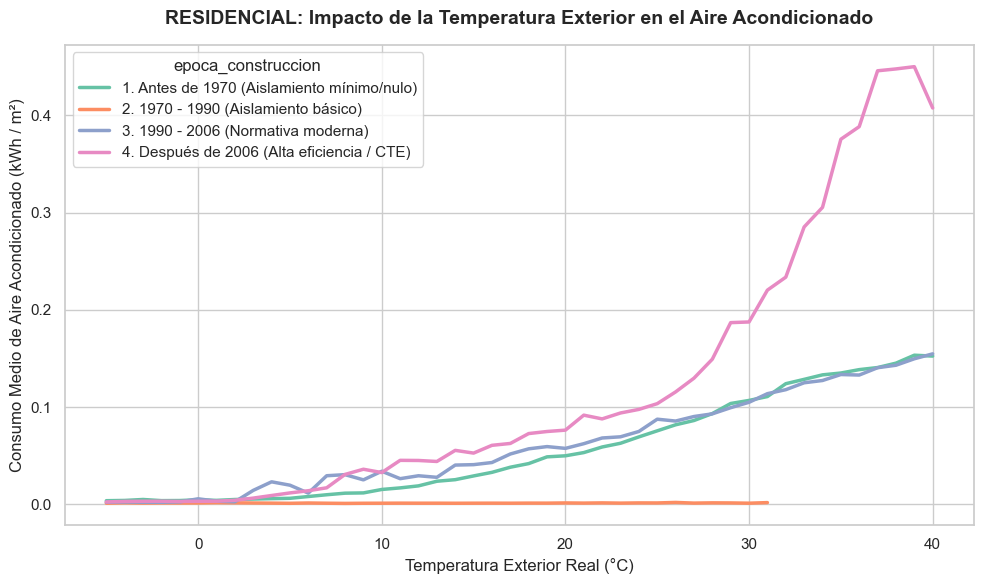

¡Gráfico de Gemelo Digital Residencial generado con éxito a partir de 64,240 lecturas!


In [21]:
# 1. FILTRADO CON LA ETIQUETA EXACTA PARA RESIDENCIAL
df_clima_residencial = df_residencial[df_residencial['tipo_consumo'] == 'Agua refrigerada (AC)'].copy()

# Limpieza climática: filtramos el rango lógico de temperaturas (-5°C a 40°C)
df_clima_residencial = df_clima_residencial[(df_clima_residencial['airTemperature'] >= -5) & (df_clima_residencial['airTemperature'] <= 40)]

# Redondeamos la temperatura exterior a números enteros
df_clima_residencial['temp_entera'] = df_clima_residencial['airTemperature'].round()

# 2. AGRUPACIÓN: Calcular el consumo medio residencial por cada grado de temperatura y época
df_correlacion_res = df_clima_residencial.groupby(['temp_entera', 'epoca_construccion'])['kwh_per_sqm'].mean().reset_index()

# 3. DIBUJAR GRÁFICO DE LÍNEAS (Firma Energética Residencial)
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_correlacion_res, 
    x='temp_entera', 
    y='kwh_per_sqm', 
    hue='epoca_construccion', 
    palette='Set2',
    linewidth=2.5
)

# Personalización del gráfico técnico
plt.title('RESIDENCIAL: Impacto de la Temperatura Exterior en el Aire Acondicionado', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Temperatura Exterior Real (°C)', fontsize=12)
plt.ylabel('Consumo Medio de Aire Acondicionado (kWh / m²)', fontsize=12)
plt.tight_layout()

# Guardar automáticamente en tu repositorio de imágenes para el PowerPoint
plt.savefig('../graficos/03b_firma_energetica_residencial.png', dpi=300)
plt.show()

print(f"¡Gráfico de Gemelo Digital Residencial generado con éxito a partir de {df_clima_residencial.shape[0]:,} lecturas!")